This notebook performs the annotation comparison for Bacillus subtilis 168.
We first align everything to check the agreement among tools, and then compare those annotations

In [1]:
import pandas as pd
from upsetplot import UpSet
import gff3_parser
import numpy as np

### 1. Load data
We first load the gff files from the pipeline, parse them with gff3 parser and download the GenBank's file

In [2]:
prokka_gff_path = "../results/prokka/bacillus_prokka/bacillus.gff"
pgap_gff_path = "../results/pgap/bacillus_pgap/annot.gff"
bakta_gff_path = "../results/bakta/bacillus_bakta/bacillus.gff3"
eggnog_gff_path = "../results/eggnog/bacillus_eggnog/bacillus.emapper.decorated.gff"

In [3]:
!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gff.gz
!gunzip GCF_000009045.1_ASM904v1_genomic.gff.gz
!mv GCF_000009045.1_ASM904v1_genomic.gff bacillus_genbank.gff
ncbi_faa_path = "bacillus_genbank.gff"

--2025-11-06 09:21:14--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gff.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.7, 130.14.250.10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 550736 (538K) [application/x-gzip]
Saving to: ‘GCF_000009045.1_ASM904v1_genomic.gff.gz’

GCF_000009045.1_ASM 100%[===================>] 537.83K   771KB/s    in 0.7s    

2025-11-06 09:21:16 (771 KB/s) - ‘GCF_000009045.1_ASM904v1_genomic.gff.gz’ saved [550736/550736]



In [4]:
eggnog_gff = gff3_parser.parse_gff3(eggnog_gff_path, parse_attributes=True)

# removing FASTA section from prokka gff
with open(prokka_gff_path, 'r') as file, open('bacillus_prokka_cleaned.gff', 'w') as outfile:
    for line in file:
        if line.startswith('##FASTA'):
            break
        outfile.write(line)

prokka_gff = gff3_parser.parse_gff3('bacillus_prokka_cleaned.gff', parse_attributes=True)
pgap_gff = gff3_parser.parse_gff3(pgap_gff_path, parse_attributes=True)
bakta_gff = gff3_parser.parse_gff3(bakta_gff_path, parse_attributes=True)
genbank_gff = gff3_parser.parse_gff3('bacillus_genbank.gff', parse_attributes=True) 

 Sequence Data: seqnum=1;seqlen=4215606;seqhdr="bacillus"
 Model Data: version=Prodigal.v2.6.3;run_type=Single;model="Ab initio";gc_cont=43.51;transl_table=11;uses_sd=1
Building structured data...


100%|██████████| 4230/4230 [00:00<00:00, 776927.04it/s]


Adding Supplemental Attribute table...
Finding unique attribute keys...


100%|██████████| 4226/4226 [00:00<00:00, 387079.16it/s]


Making attribute table...


...

100%|██████████| 9296/9296 [00:00<00:00, 1293208.95it/s]


Adding Supplemental Attribute table...
Finding unique attribute keys...


/home/bruno/miniconda3/envs/benchannot/lib/python3.11/site-packages/gff3_parser/parser.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.DataFrame(data).replace('.', np.nan)
100%|██████████| 9288/9288 [00:00<00:00, 904644.25it/s]


Making attribute table...


100%|██████████| 9288/9288 [00:00<00:00, 230390.30it/s]


In [5]:
eggnog_gff.rename(columns={"em_desc":"product", "em_Preferred_name":"gene"}, inplace=True)
eggnog_gff["Source"] = "Eggnog-Mapper"
bakta_gff["Source"] = "Bakta"
prokka_gff["Source"] = "Prokka"
pgap_gff["Source"] = "PGAP"
genbank_gff["Source"] = "GenBank"



### 2. UpSet Plot
Now we can combine all GFF files, retain only relevant information, and check whether gene predictions are consistent across them through an UpSet plot

In [6]:
# combining all annotations into a single DataFrame
all_gffs = pd.concat([eggnog_gff, bakta_gff, prokka_gff, pgap_gff, genbank_gff], ignore_index=True)
all_gffs = all_gffs[all_gffs["Type"]=="CDS"]

In [7]:
all_gffs.drop(columns=["Phase", "Score", "rbs_spacer","anticodon","transl_table","strain","function","old_locus_tag","type-material","sub-species","Is_circular",
                       "em_tcov","mol_type","genome","bound_moiety","exception","gene_biotype","gbkey","gene_synonym","exception","tag_peptide","em_evalue",
                       "protein_id","uscore","Parent","sscore","em_target","em_max_annot_lvl","regulatory_class","em_KEGG_rclass","em_CAZy","cscore","em_BiGG_Reaction",
                       "ncRNA_class","partial","locus_tag","anti_codon","inference","amino_acid","pseudogene","conf","em_PFAMs","em_KEGG_TC","em_ID",
                       "rbs_motif","rscore"],inplace=True)

In [8]:
all_gffs['orf_id'] = all_gffs['Start'].astype(str) + '_' + all_gffs['End'].astype(str)


/home/bruno/miniconda3/envs/benchannot/lib/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/bruno/miniconda3/envs/benchannot/lib/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we ar

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

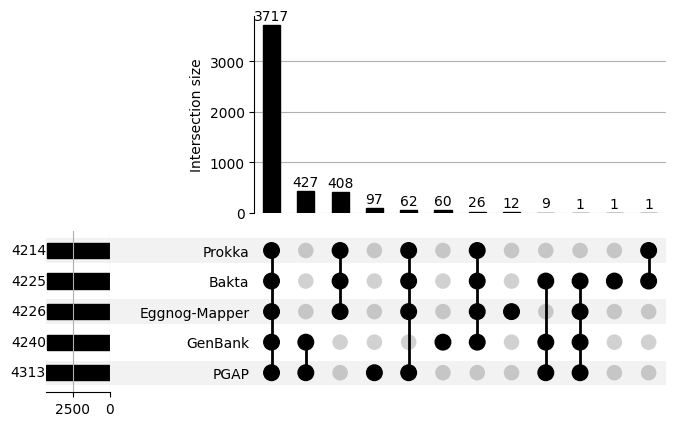

In [9]:
indicators = pd.crosstab(all_gffs["orf_id"], all_gffs["Source"]).astype(bool)
from upsetplot import UpSet, from_indicators
df_upset = from_indicators(indicators)
upset = UpSet(df_upset, subset_size='count', show_counts='%d',
              sort_by="cardinality", sort_categories_by='cardinality')
upset.plot()

### 3. Annotation analysis
Now we proceed to checking if the functional annotation differs. Starting with the biggest group (3717 CDSs that were the same for all tools). 